In [1]:
import json_tricks
import torch
import numpy as np
import matplotlib.pyplot as plt
import random

# This is important for reproducibility
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.set_default_dtype(torch.float64)

if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

answer = {}

# Preparation

In this notebook, we will be working on a toy problem of reconstructing the hidden 
dependency. We will work with a synthetic dataset. As a basic example, we will
start with data

$$f(x) = \sin(x) + \epsilon,$$

where $\epsilon$ is random noise that simulates measurement inaccuracies.

Our task will be to prepare a network $Net(x)$ that will accept a single value $x$
as an argument and yield a single value $y$ as a forecast.

Ideally, the network should be as close to the hidden dependency as possible:

$$Net(x) \rightarrow \sin(x)$$

We will create all the modules that are necessary to train a network:
- network (two-layer FCNN)
- loss function (MSE)
- optimizer (AdamW)

We will also create a training cycle that consists of:
- forward step
- loss calculation
- backpropagation
- optimizer step

# Generating the dataset

First, we will generate the clean samples

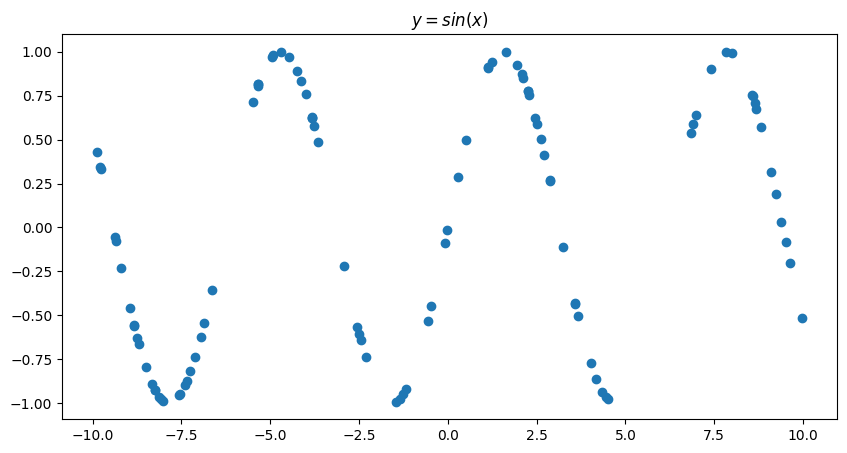

In [2]:
import torch
import matplotlib.pyplot as plt

import matplotlib
matplotlib.rcParams['figure.figsize'] = (10.0, 5.0)

x_train = torch.rand(100)
x_train = x_train * 20.0 - 10.0

y_train = torch.sin(x_train)

plt.plot(x_train.numpy(), y_train.numpy(), 'o')
plt.title('$y = sin(x)$');

Second, generate the noise that will be added to the training data

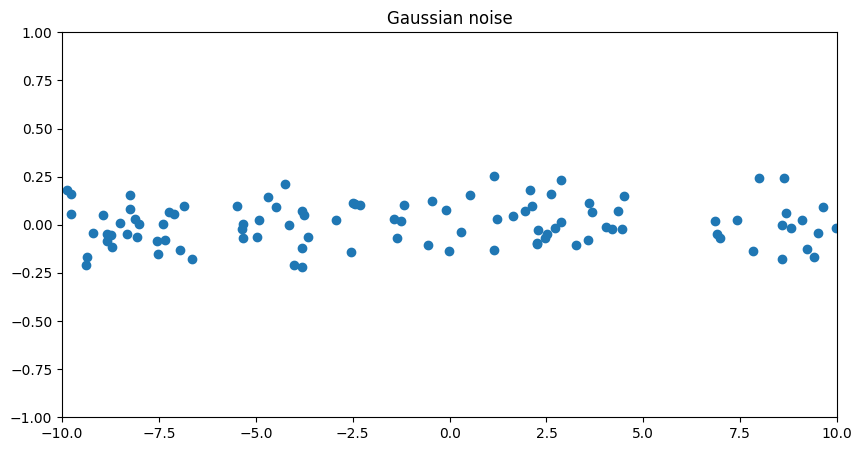

In [3]:
noise = torch.randn(y_train.shape) / 10.

plt.plot(x_train.numpy(), noise.numpy(), 'o')
plt.axis([-10, 10, -1, 1])
plt.title('Gaussian noise');

Finally, add the noise to the clean data and get the spoiled data that we will use for training

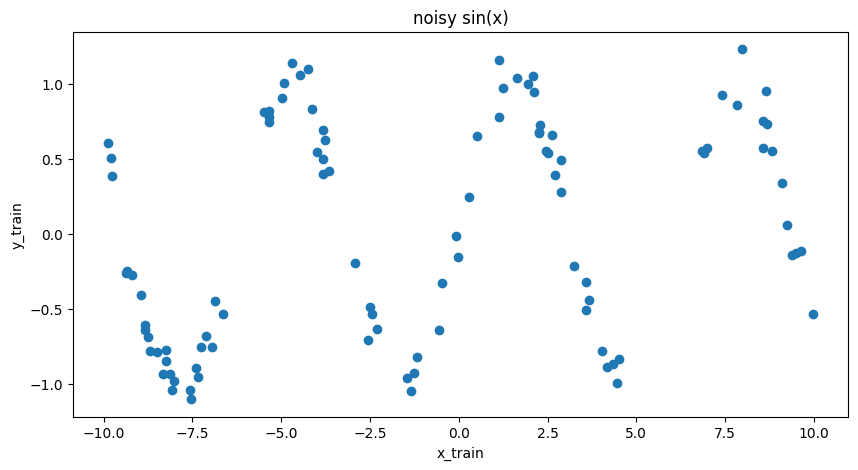

In [4]:
y_train = y_train + noise
plt.plot(x_train.numpy(), y_train.numpy(), 'o')
plt.title('noisy sin(x)')
plt.xlabel('x_train')
plt.ylabel('y_train');

In [5]:
x_train.unsqueeze_(1);
y_train.unsqueeze_(1);

# Validation dataset

For validation we will use only clean, equally spaced data. Thus we will not generate noise for this set.

torch.float64
tensor([-10.0000,  -9.7980,  -9.5960,  -9.3939,  -9.1919,  -8.9899,  -8.7879,
         -8.5859,  -8.3838,  -8.1818,  -7.9798,  -7.7778,  -7.5758,  -7.3737,
         -7.1717,  -6.9697,  -6.7677,  -6.5657,  -6.3636,  -6.1616,  -5.9596,
         -5.7576,  -5.5556,  -5.3535,  -5.1515,  -4.9495,  -4.7475,  -4.5455,
         -4.3434,  -4.1414,  -3.9394,  -3.7374,  -3.5354,  -3.3333,  -3.1313,
         -2.9293,  -2.7273,  -2.5253,  -2.3232,  -2.1212,  -1.9192,  -1.7172,
         -1.5152,  -1.3131,  -1.1111,  -0.9091,  -0.7071,  -0.5051,  -0.3030,
         -0.1010,   0.1010,   0.3030,   0.5051,   0.7071,   0.9091,   1.1111,
          1.3131,   1.5152,   1.7172,   1.9192,   2.1212,   2.3232,   2.5253,
          2.7273,   2.9293,   3.1313,   3.3333,   3.5354,   3.7374,   3.9394,
          4.1414,   4.3434,   4.5455,   4.7475,   4.9495,   5.1515,   5.3535,
          5.5556,   5.7576,   5.9596,   6.1616,   6.3636,   6.5657,   6.7677,
          6.9697,   7.1717,   7.3737,   7.5758,   

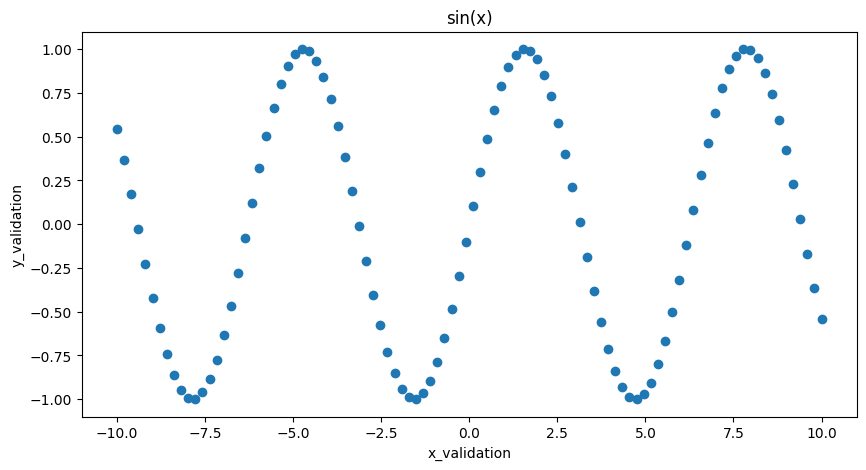

In [6]:
x_validation = torch.linspace(-10, 10, 100)
y_validation = torch.sin(x_validation.data)
plt.plot(x_validation.numpy(), y_validation.numpy(), 'o')
plt.title('sin(x)')
plt.xlabel('x_validation')
plt.ylabel('y_validation');

print(x_validation.dtype)
print(x_validation)

In [7]:
x_validation.unsqueeze_(1)
y_validation.unsqueeze_(1);

# Model construction

Fill out the class for a two-layer feedforward neural network with a sigmoid hidden layer.

The class should consist of two methods:
* `__init__` -- constructor, where the layers should be defined as follows:
    * `Linear 1 -> n_hidden_neurons`
    * `sigmoid` activation
    * `Linear n_hidden_neurons -> 1`
* `forward` -- pass the signal through the network:
    * `x -> linear 1 -> sigmoid -> linear 2`

In [8]:
class SineNet(torch.nn.Module):
    def __init__(self, n_hidden_neurons):
        super().__init__()
        self.linear1 = torch.nn.Linear(1, n_hidden_neurons)
        self.sigmoid = torch.nn.Sigmoid()
        self.linear2 = torch.nn.Linear(n_hidden_neurons, 1)

    def forward(self, x):
        x = self.linear1(x)
        x = self.sigmoid(x)
        x = self.linear2(x)
        return x

sine_net = SineNet(20)

# Prediction

Here, we will make a prediction using our neural network. The main method here is `forward` that we have programmed within our `torch.Module` class.

Below we will plot the predictions to understand how they are related to the validation data.

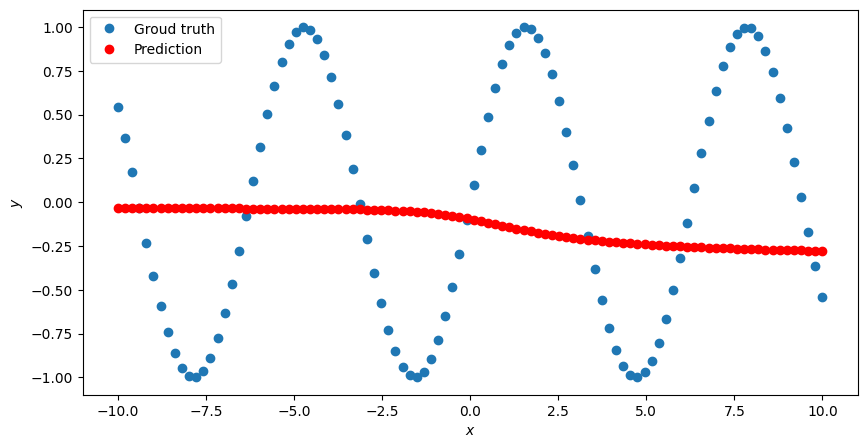

In [9]:
y_pred = sine_net.forward(x_validation)
answer['init_pred'] = y_pred.detach().numpy()

def predict(net, x, y):
    y_pred = net.forward(x)

    plt.plot(x.numpy(), y.numpy(), 'o', label='Groud truth')
    plt.plot(x.numpy(), y_pred.data.numpy(), 'o', c='r', label='Prediction');
    plt.legend(loc='upper left')
    plt.xlabel('$x$')
    plt.ylabel('$y$')

predict(sine_net, x_validation, y_validation)

We see that the untrained neural network predicts something, maybe even some dependency, but it is not related to the dependency that we want to reconstruct. 

Now let us train the network (tune the parameters to minimize the misfit between the labels and predictions).

# Loss function

Now we will define the function that measures the misfit.

The requirements for this function are:
* the lower the loss is, the better the predictions are
* the slope should be nonzero for the majority of the locations

In our case, it will be mean squared error:
$$\frac{1}{N} \sum_{i=1}^N \left(Net(x_i) - t_i\right)^2$$

The lower this deviation is, the closer the neural network prediction is to the target.

Code this loss function. Note that `pred` and `target` are vectors.

In [17]:
def loss(pred, target):
    return ((pred - target) ** 2).sum() / target.shape[0]

answer['loss'] = [loss(torch.tensor([v]), torch.tensor([0])).detach().numpy() for v in np.linspace(-10, 10, 100)]

# Optimizer

Now we have to tune the parameters by minimizing the loss function. Select `AdamW` optimizer from `torch.optim`.

As the first argument, pass which parameters the optimizer should update. You can access the whole set of parameters of `torch.Module` using the `parameters()` method.

Set `lr` (learning rate) to `1.0e-2`.

In [18]:
optimizer = torch.optim.AdamW(sine_net.parameters(), lr=1.0e-2)

# Training procedure

Now everything is ready for training.

Build the training cycle from the following steps:
1. reset the gradients for trainable weights (`zero_grad()` method of the optimizer)
2. forward signal propagation through the network (take the vector of input signals `x_train` and call the `forward` method of the `torch.nn.Module` with that `x_train` as an argument)
3. loss value computation (take `loss` that we created above and compute the misfit of prediction and target labels `y_train`)
4. backpropagation through the network, computation of loss derivatives with respect to every weight of the network (`backward` method of `torch.nn.Module`)
5. optimizer step after all gradients for the weights are known (`step` method of the `Optimizer`)

Repeat the steps above a certain number of times, say `1000`, and observe the change in the network predictions.

100%|██████████| 2000/2000 [00:02<00:00, 719.79it/s]


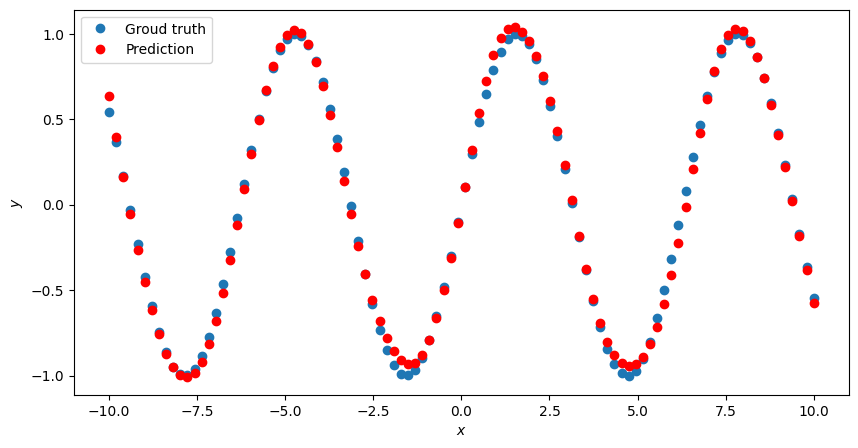

In [20]:
from tqdm import trange
for epoch_index in trange(2000):
    optimizer.zero_grad()
    preds = sine_net.forward(x_train)
    loss_value = loss(preds, y_train)
    loss_value.backward()
    optimizer.step()

y_pred = sine_net.forward(x_validation)
answer['trained_pred'] = y_pred.detach().numpy()

predict(sine_net, x_validation, y_validation)

In [21]:
import lovely_tensors as lt
lt.monkey_patch()

print(x_train.dtype)
print(y_train.dtype)
print(x_train)
print(y_train)
print(x_validation)


torch.float64
torch.float64
tensor[100, 1] f64 x∈[-9.867, 9.969] μ=-0.997 σ=6.032
tensor[100, 1] f64 x∈[-1.100, 1.233] μ=0.040 σ=0.729
tensor[100, 1] f64 x∈[-10.000, 10.000] μ=-3.553e-17 σ=5.861


# Conclusion

In this notebook, we have covered all of the steps that the coder encounters while programming the training procedure of a neural network.

In serious projects every part of this process contains tons of code, but the philosophy everywhere is the same:

* Get data
* Define the network
* Define the loss
* Select optimizer
* Run training cycle

In [22]:
json_tricks.dump(answer, open('.answer.json', 'w'))

'{"init_pred": {"__ndarray__": [[-0.0334155170432712], [-0.03350426552420796], [-0.03359759483622102], [-0.03369590087459093], [-0.03379958125259491], [-0.03390903128948755], [-0.03402463949036735], [-0.03414678254185119], [-0.03427581987878606], [-0.034412087919831136], [-0.034555894126773096], [-0.034707511117730294], [-0.03486717116263088], [-0.035035061516110355], [-0.03521132120488754], [-0.035396040091420056], [-0.03558926129186374], [-0.035790988343480545], [-0.036001198904382054], [-0.03621986723595011], [-0.03644699827257336], [-0.03668267672725892], [-0.03692713541037168], [-0.03718084773477362], [-0.03744465020718693], [-0.03771990149745599], [-0.038008685329260106], [-0.038314064788536495], [-0.03864039547078929], [-0.03899370387263831], [-0.03938213516852124], [-0.03981647049749526], [-0.0403107075394159], [-0.04088268888308755], [-0.0415547499564006], [-0.042354341815087765], [-0.04331456406854936], [-0.04447452065870974], [-0.04587938829772484], [-0.04758006791336619], [